# Model — LGBM + Optuna + Calibración

Lee `data/features_v2.parquet` y recomputa el target desde `data/txn_sample.parquet`. Entrena LGBM tuneado con Optuna, lo compara contra baseline LR L2, calibra con isotonic/sigmoid y persiste modelo + scores.

In [37]:
import warnings, logging
warnings.filterwarnings("ignore")
logging.getLogger("lightgbm").setLevel(logging.ERROR)

import polars as pl
import numpy as np
import lightgbm as lgb
import optuna
import joblib
from pathlib import Path
from sklearn.base import clone
from sklearn.model_selection import RepeatedStratifiedKFold, StratifiedKFold, train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import average_precision_score, roc_auc_score, brier_score_loss, precision_recall_curve, roc_curve
import matplotlib.pyplot as plt

from src import clip_palette as cs
cs.apply()

DATA = Path("data")
SEED = 42
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [38]:
import os

ACTIVITY_FLOOR = 10
TARGET_PCT     = 97   
#Valores definidos en el notebook de EDA

FEATURES = Path(os.environ.get("FEATURES_PATH", DATA / "features_v2.parquet"))

agg_all = (
    pl.scan_parquet(DATA / "txn_sample.parquet")
    .group_by("merchant_id").agg([
        pl.len().alias("n_txn"),
        pl.col("amount").sum().alias("tpv_total"),
        pl.when(pl.col("is_fraud") == 1).then(pl.col("amount")).otherwise(0).sum().alias("tpv_fraud"),
    ])
    .with_columns((pl.col("tpv_fraud") / pl.col("tpv_total")).fill_nan(0).alias("fraud_rate_tpv"))
    .filter(pl.col("n_txn") >= ACTIVITY_FLOOR)
    .collect()
)

UMBRAL = float(np.percentile(agg_all["fraud_rate_tpv"].to_numpy(), TARGET_PCT))
agg = agg_all.select(
    "merchant_id", "tpv_total", "tpv_fraud", "fraud_rate_tpv",
    pl.col("fraud_rate_tpv").gt(UMBRAL).cast(pl.Int8).alias("y"),
)

feat = pl.read_parquet(FEATURES)


data = feat.join(agg, on="merchant_id", how="inner").sort("merchant_id")

X_cols = [c for c in feat.columns if c not in ("merchant_id", "industry_mcc")]
X         = data.select(X_cols).to_numpy()
y         = data["y"].to_numpy()
tpv       = data["tpv_total"].to_numpy()
tpv_fraud = data["tpv_fraud"].to_numpy()   # pérdida real observada, para evaluar el ranking
mid       = data["merchant_id"].to_numpy()

idx_tr, idx_te = train_test_split(np.arange(len(y)), test_size=0.3, stratify=y, random_state=SEED)
X_tr, X_te = X[idx_tr], X[idx_te]
y_tr, y_te = y[idx_tr], y[idx_te]

print(f"features: {FEATURES.name}")
print(f"target: fraud_rate_tpv > P{TARGET_PCT} = {UMBRAL:.6g}")
print(f"n={len(y):,} | prevalencia={y.mean():.2%} | features={len(X_cols)} | train={len(y_tr):,} | test={len(y_te):,}")
print(f"TPV fraudulento total en test: {tpv_fraud[idx_te].sum():,.0f}")

features: features_v2.parquet
target: fraud_rate_tpv > P97 = 0.00129852
n=23,083 | prevalencia=3.00% | features=50 | train=16,158 | test=6,925
TPV fraudulento total en test: 2,293,426


In [39]:
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=SEED)

def summarize(scores, label):
    m, s, n = scores.mean(), scores.std(), len(scores)
    ci = (m - 1.96 * s / np.sqrt(n), m + 1.96 * s / np.sqrt(n))
    print(f"{label:22s} PR-AUC = {m:.4f} ± {s:.4f}   IC95≈[{ci[0]:.4f}, {ci[1]:.4f}]")
    return {"mean": m, "std": s, "ci": ci, "scores": scores}


tpv_tr = tpv[idx_tr]
scores_vol = np.array([
    average_precision_score(y_tr[va], tpv_tr[va]) for _, va in cv.split(X_tr, y_tr)
])

# LR no soporta NaN → imputar mediana (LGBM sí los maneja nulos).

lr = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler(),
    LogisticRegression(penalty="l2", C=1.0, max_iter=1000, random_state=SEED),
)
neg, pos = (y_tr == 0).sum(), (y_tr == 1).sum()
lgb_default = lgb.LGBMClassifier(scale_pos_weight=neg / pos, random_state=SEED, verbosity=-1)

scores_lr  = cross_val_score(lr,          X_tr, y_tr, cv=cv, scoring="average_precision", n_jobs=-1)
scores_lgb = cross_val_score(lgb_default, X_tr, y_tr, cv=cv, scoring="average_precision", n_jobs=-1)

vol_stats = summarize(scores_vol, "BASELINE volumen")
lr_stats  = summarize(scores_lr,  "LR L2 baseline")
lgb_stats = summarize(scores_lgb, "LGBM defaults")
print(f"\nprevalencia (modelo nulo)  PR-AUC = {y_tr.mean():.4f}")

BASELINE volumen       PR-AUC = 0.1035 ± 0.0225   IC95≈[0.0947, 0.1123]
LR L2 baseline         PR-AUC = 0.1338 ± 0.0241   IC95≈[0.1244, 0.1433]
LGBM defaults          PR-AUC = 0.1391 ± 0.0226   IC95≈[0.1302, 0.1479]

prevalencia (modelo nulo)  PR-AUC = 0.0300


In [40]:
def objective(trial):
    params = {
        "objective":         "binary",
        "metric":            "average_precision",
        "verbosity":         -1,
        "num_leaves":        trial.suggest_int("num_leaves", 15, 128),
        "min_child_samples": trial.suggest_int("min_child_samples", 20, 500),
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "feature_fraction":  trial.suggest_float("feature_fraction", 0.5, 1.0),
        "bagging_fraction":  trial.suggest_float("bagging_fraction", 0.5, 1.0),
        "bagging_freq":      trial.suggest_int("bagging_freq", 1, 7),
        "lambda_l1":         trial.suggest_float("lambda_l1", 1e-3, 10.0, log=True),
        "lambda_l2":         trial.suggest_float("lambda_l2", 1e-3, 10.0, log=True),
        "max_depth":         trial.suggest_int("max_depth", 3, 12),
        "scale_pos_weight":  trial.suggest_float("scale_pos_weight", 1.0, 30.0),
    }
    skf = StratifiedKFold(5, shuffle=True, random_state=SEED)
    scores = []
    for tr, va in skf.split(X_tr, y_tr):
        tr_fit, tr_es = train_test_split(
            tr, test_size=0.2, stratify=y_tr[tr], random_state=SEED
        )
        m = lgb.LGBMClassifier(**params, n_estimators=1000, random_state=SEED)
        m.fit(
            X_tr[tr_fit], y_tr[tr_fit],
            eval_set=[(X_tr[tr_es], y_tr[tr_es])],
            callbacks=[lgb.early_stopping(50, verbose=False)],
        )
        scores.append(average_precision_score(y_tr[va], m.predict_proba(X_tr[va])[:, 1]))
    return float(np.mean(scores))

study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=100, show_progress_bar=True)
best_params = study.best_params
print(f"\nbest PR-AUC (CV interna): {study.best_value:.4f}")
print(f"best params: {best_params}")

Best trial: 89. Best value: 0.18633: 100%|██████████| 100/100 [09:07<00:00,  5.47s/it]


best PR-AUC (CV interna): 0.1863
best params: {'num_leaves': 21, 'min_child_samples': 83, 'learning_rate': 0.014646319017228319, 'feature_fraction': 0.5488197202346743, 'bagging_fraction': 0.9151983369257326, 'bagging_freq': 4, 'lambda_l1': 0.027922321107026, 'lambda_l2': 1.4162678642906714, 'max_depth': 12, 'scale_pos_weight': 1.0281238032843083}


In [41]:
lgb_optuna = lgb.LGBMClassifier(**best_params, n_estimators=500, random_state=SEED, verbosity=-1)
scores_opt = cross_val_score(lgb_optuna, X_tr, y_tr, cv=cv, scoring="average_precision", n_jobs=-1)
opt_stats  = summarize(scores_opt, "LGBM Optuna")
print("\n(los hiperparámetros se eligieron sobre este mismo X_tr, así que este número\n"
      " es algo optimista — el juez limpio es el test)")

rng = np.random.default_rng(SEED)
for label, ref in [("BASELINE volumen", scores_vol), ("LR L2", scores_lr)]:
    delta = scores_opt - ref
    boot  = np.array([rng.choice(delta, size=len(delta), replace=True).mean() for _ in range(2000)])
    lo, hi = np.percentile(boot, [2.5, 97.5])
    veredicto = "IC no cruza 0" if lo > 0 else "IC CRUZA 0"
    print(f"Δ(LGBM Optuna − {label:16s}) = {delta.mean():+.4f}  IC95=[{lo:+.4f}, {hi:+.4f}]  {veredicto}")
print("\n(el IC del bootstrap subestima la incertidumbre: los folds comparten merchants)")

LGBM Optuna            PR-AUC = 0.1753 ± 0.0262   IC95≈[0.1651, 0.1856]

(los hiperparámetros se eligieron sobre este mismo X_tr, así que este número
 es algo optimista — el juez limpio es el test)
Δ(LGBM Optuna − BASELINE volumen) = +0.0718  IC95=[+0.0622, +0.0808]  IC no cruza 0
Δ(LGBM Optuna − LR L2           ) = +0.0415  IC95=[+0.0329, +0.0500]  IC no cruza 0

(el IC del bootstrap subestima la incertidumbre: los folds comparten merchants)


                         PR-AUC   ROC-AUC
BASELINE volumen         0.0893    0.7118
LR L2                    0.1362    0.7597
LGBM Optuna              0.1703    0.7842
modelo nulo (prev.)      0.0300    0.5000

LGBM test: Brier=0.0270  best_iter=155


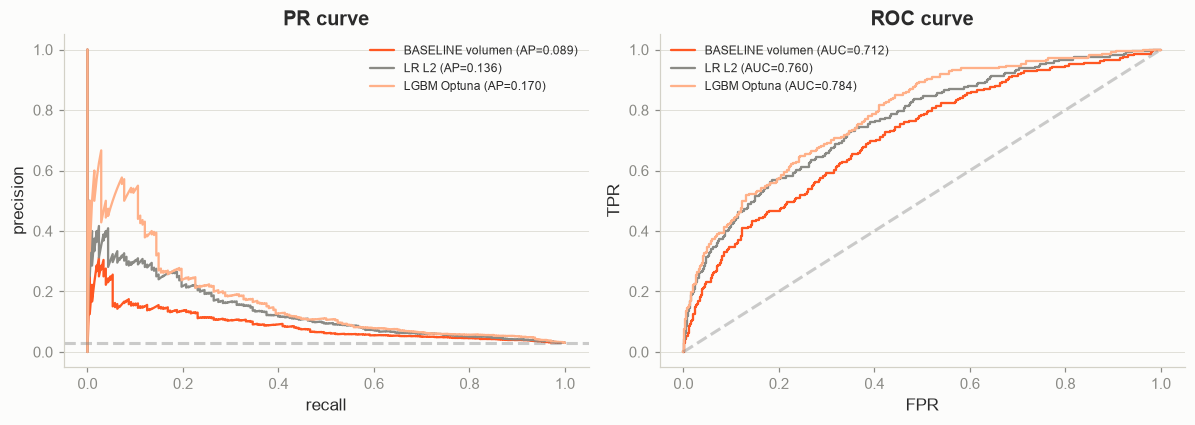

In [42]:
idx_fit, idx_val = train_test_split(np.arange(len(y_tr)), test_size=0.2, stratify=y_tr, random_state=SEED)

lgbm_final = lgb.LGBMClassifier(**best_params, n_estimators=2000, random_state=SEED, verbosity=-1)
lgbm_final.fit(
    X_tr[idx_fit], y_tr[idx_fit],
    eval_set=[(X_tr[idx_val], y_tr[idx_val])],
    callbacks=[lgb.early_stopping(50, verbose=False)],
)
best_iter = lgbm_final.best_iteration_ or lgbm_final.n_estimators

# LR entrenada en train para poder compararla también en test
lr_final = clone(lr).fit(X_tr, y_tr)

p_te_raw = lgbm_final.predict_proba(X_te)[:, 1]
p_te_lr  = lr_final.predict_proba(X_te)[:, 1]
p_te_vol = tpv[idx_te]   # baseline: el score ES el TPV

print(f"{'':22s} {'PR-AUC':>8} {'ROC-AUC':>9}")
for label, p in [("BASELINE volumen", p_te_vol), ("LR L2", p_te_lr), ("LGBM Optuna", p_te_raw)]:
    print(f"{label:22s} {average_precision_score(y_te, p):>8.4f} {roc_auc_score(y_te, p):>9.4f}")
print(f"{'modelo nulo (prev.)':22s} {y_te.mean():>8.4f} {0.5:>9.4f}")

pr_auc_test  = average_precision_score(y_te, p_te_raw)
roc_auc_test = roc_auc_score(y_te, p_te_raw)
brier_test   = brier_score_loss(y_te, p_te_raw)
print(f"\nLGBM test: Brier={brier_test:.4f}  best_iter={best_iter}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for label, p in [("BASELINE volumen", p_te_vol), ("LR L2", p_te_lr), ("LGBM Optuna", p_te_raw)]:
    prec, rec, _ = precision_recall_curve(y_te, p)
    axes[0].plot(rec, prec, lw=1.5, label=f"{label} (AP={average_precision_score(y_te, p):.3f})")
    fpr, tpr, _ = roc_curve(y_te, p)
    axes[1].plot(fpr, tpr, lw=1.5, label=f"{label} (AUC={roc_auc_score(y_te, p):.3f})")
axes[0].axhline(y_te.mean(), ls="--", alpha=0.4, color="gray")
axes[0].set(xlabel="recall", ylabel="precision", title="PR curve"); axes[0].legend(fontsize=8)
axes[1].plot([0,1],[0,1], "--", alpha=0.4, color="gray")
axes[1].set(xlabel="FPR", ylabel="TPR", title="ROC curve"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

In [43]:
def ece(y_true, y_pred, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    idx  = np.clip(np.digitize(y_pred, bins) - 1, 0, n_bins - 1)
    err  = 0.0
    for b in range(n_bins):
        m = idx == b
        if not m.any(): continue
        err += m.mean() * abs(y_pred[m].mean() - y_true[m].mean())
    return float(err)


idx_cfit, idx_csel = train_test_split(
    np.arange(len(y_tr)), test_size=0.25, stratify=y_tr, random_state=SEED + 1
)

def _new_est():
    return lgb.LGBMClassifier(**best_params, n_estimators=best_iter, random_state=SEED, verbosity=-1)

sel_scores = {"raw": ece(
    y_tr[idx_csel],
    _new_est().fit(X_tr[idx_cfit], y_tr[idx_cfit]).predict_proba(X_tr[idx_csel])[:, 1],
)}
for method in ("isotonic", "sigmoid"):
    c = CalibratedClassifierCV(_new_est(), cv=5, method=method, n_jobs=-1).fit(X_tr[idx_cfit], y_tr[idx_cfit])
    sel_scores[method] = ece(y_tr[idx_csel], c.predict_proba(X_tr[idx_csel])[:, 1])

print("ECE en el holdout de train (criterio de elección):")
for k, v in sorted(sel_scores.items(), key=lambda kv: kv[1]):
    print(f"  {k:10s} {v:.4f}")

best_name = min(sel_scores, key=sel_scores.get)
print(f"\ncalibrador elegido: {best_name}")

# El ganador se reentrena con todo el train
if best_name == "raw":
    best_cal, p_te_best = lgbm_final, p_te_raw
else:
    best_cal  = CalibratedClassifierCV(_new_est(), cv=5, method=best_name, n_jobs=-1).fit(X_tr, y_tr)
    p_te_best = best_cal.predict_proba(X_te)[:, 1]

ECE en el holdout de train (criterio de elección):
  raw        0.0060
  sigmoid    0.0065
  isotonic   0.0071

calibrador elegido: raw


shape: (1, 3)
┌─────┬──────────┬──────────┐
│ cal ┆ Brier    ┆ ECE      │
│ --- ┆ ---      ┆ ---      │
│ str ┆ f64      ┆ f64      │
╞═════╪══════════╪══════════╡
│ raw ┆ 0.026973 ┆ 0.000952 │
└─────┴──────────┴──────────┘


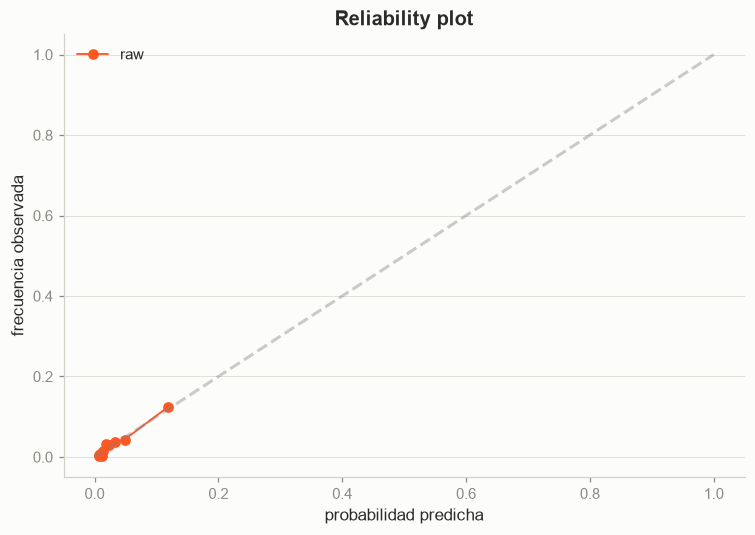

In [44]:
results = {"raw": p_te_raw, f"{best_name}": p_te_best}
print(pl.DataFrame([
    {"cal": k, "Brier": brier_score_loss(y_te, v), "ECE": ece(y_te, v)}
    for k, v in results.items()
]))

fig, ax = plt.subplots(figsize=(7, 5))
for name, p in results.items():
    q  = np.quantile(p, np.linspace(0, 1, 11))
    ix = np.clip(np.digitize(p, q, right=True) - 1, 0, 9)
    xs = [p[ix == b].mean()    if (ix == b).any() else np.nan for b in range(10)]
    ys = [y_te[ix == b].mean() if (ix == b).any() else np.nan for b in range(10)]
    ax.plot(xs, ys, "o-", lw=1.2, label=name)
ax.plot([0, 1], [0, 1], "--", alpha=0.4, color="gray")
ax.set(xlabel="probabilidad predicha", ylabel="frecuencia observada", title="Reliability plot")
ax.legend(); plt.tight_layout(); plt.show()

Pérdida total en test: 2,293,426  |  positivos: 208 de 6925
shape: (6, 6)
┌───────┬─────────────┬───────────────┬────────────────┬──────────────────┬─────────────────┐
│ top_K ┆ prec_modelo ┆ prec_solo_TPV ┆ perdida_modelo ┆ perdida_solo_TPV ┆ perdida_oraculo │
│ ---   ┆ ---         ┆ ---           ┆ ---            ┆ ---              ┆ ---             │
│ i64   ┆ str         ┆ str           ┆ str            ┆ str              ┆ str             │
╞═══════╪═════════════╪═══════════════╪════════════════╪══════════════════╪═════════════════╡
│ 50    ┆ 44.0%       ┆ 22.0%         ┆ 28.4%          ┆ 14.9%            ┆ 87.1%           │
│ 100   ┆ 31.0%       ┆ 17.0%         ┆ 50.4%          ┆ 35.2%            ┆ 95.4%           │
│ 200   ┆ 23.5%       ┆ 15.5%         ┆ 57.0%          ┆ 40.3%            ┆ 99.2%           │
│ 300   ┆ 19.7%       ┆ 13.3%         ┆ 58.9%          ┆ 45.6%            ┆ 100.0%          │
│ 500   ┆ 15.6%       ┆ 11.0%         ┆ 64.3%          ┆ 58.1%            ┆ 100.

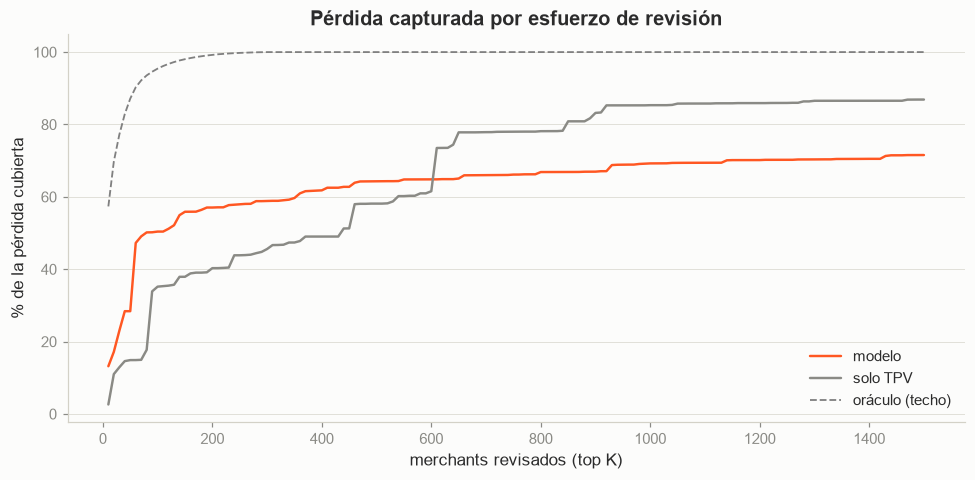

In [45]:
# Segunda funcionalidad del modelo: pérdida esperada 


tpv_f_te   = tpv_fraud[idx_te]
total_loss = tpv_f_te.sum()

rows = []
for k in [50, 100, 200, 300, 500, 1000]:
    sel_m, sel_v = np.argsort(-p_te_best)[:k], np.argsort(-p_te_vol)[:k]
    rows.append({
        "top_K":            k,
        "prec_modelo":      f"{y_te[sel_m].mean():.1%}",
        "prec_solo_TPV":    f"{y_te[sel_v].mean():.1%}",
        "perdida_modelo":   f"{tpv_f_te[sel_m].sum()/total_loss:.1%}",
        "perdida_solo_TPV": f"{tpv_f_te[sel_v].sum()/total_loss:.1%}",
        "perdida_oraculo":  f"{np.sort(tpv_f_te)[::-1][:k].sum()/total_loss:.1%}",
    })
print(f"Pérdida total en test: {total_loss:,.0f}  |  positivos: {y_te.sum()} de {len(y_te)}")
print(pl.DataFrame(rows))

ks = np.arange(10, 1501, 10)
fig, ax = plt.subplots(figsize=(9, 4.5))
for label, p in [("modelo", p_te_best), ("solo TPV", p_te_vol)]:
    o = np.argsort(-p)
    ax.plot(ks, [tpv_f_te[o[:k]].sum()/total_loss*100 for k in ks], lw=1.6, label=label)
srt = np.sort(tpv_f_te)[::-1]
ax.plot(ks, [srt[:k].sum()/total_loss*100 for k in ks], "--", lw=1.2, color="gray", label="oráculo (techo)")
ax.set(xlabel="merchants revisados (top K)", ylabel="% de la pérdida cubierta",
       title="Pérdida capturada por esfuerzo de revisión")
ax.legend(); plt.tight_layout(); plt.show()

In [46]:
# Pérdida esperada

loss_rate = float(data["fraud_rate_tpv"].to_numpy()[idx_tr][y_tr == 1].mean())
expected_loss = p_te_best * tpv[idx_te] * loss_rate
print(f"tasa de pérdida usada (media de fraud_rate_tpv en positivos de train): {loss_rate:.4%}")

scored = pl.DataFrame({
    "merchant_id":   mid[idx_te],
    "score":         p_te_best,
    "score_raw":     p_te_raw,
    "y":             y_te,
    "tpv_total":     tpv[idx_te],
    "tpv_fraud":     tpv_f_te,
    "expected_loss": expected_loss,
}).sort("expected_loss", descending=True)
scored.write_parquet(DATA / "merchant_scores.parquet")

joblib.dump(lgbm_final, DATA / "model_lgbm.joblib")
joblib.dump(best_cal,   DATA / "calibrator.joblib")
print(f"saved: model_lgbm.joblib | calibrator.joblib ({best_name}) | merchant_scores.parquet {scored.shape}")
print("\nNOTA: merchant_scores solo cubre el 30% de test. Para usarlo en producción\n"
      "hay que scorear los 23k merchants con el modelo reentrenado en todo el set.")

tasa de pérdida usada (media de fraud_rate_tpv en positivos de train): 3.4111%
saved: model_lgbm.joblib | calibrator.joblib (raw) | merchant_scores.parquet (6925, 7)

NOTA: merchant_scores solo cubre el 30% de test. Para usarlo en producción
hay que scorear los 23k merchants con el modelo reentrenado en todo el set.


In [47]:
def _fila(nombre, p, cv_stats=None):
    sel = np.argsort(-p)[:300]
    return {
        "modelo":          nombre,
        "PR-AUC (CV)":     cv_stats["mean"] if cv_stats else None,
        "PR-AUC (test)":   float(average_precision_score(y_te, p)),
        "ROC-AUC (test)":  float(roc_auc_score(y_te, p)),
        "prec@300":        float(y_te[sel].mean()),
        "pérdida@300":     float(tpv_f_te[sel].sum() / total_loss),
    }

resumen = pl.DataFrame([
    _fila("BASELINE volumen",  p_te_vol,  vol_stats),
    _fila("LR L2",             p_te_lr,   lr_stats),
    _fila("LGBM Optuna (raw)", p_te_raw,  opt_stats),
    _fila(f"LGBM {best_name}", p_te_best),
])
print(resumen)

print(f"\nGanancia sobre el baseline de volumen:")
print(f"  PR-AUC : {average_precision_score(y_te, p_te_best) - average_precision_score(y_te, p_te_vol):+.4f}")
print(f"  ROC-AUC: {roc_auc_score(y_te, p_te_best) - roc_auc_score(y_te, p_te_vol):+.4f}")

# Importancia de features 
imp = (
    pl.DataFrame({"feature": X_cols, "gain": lgbm_final.booster_.feature_importance("gain")})
    .sort("gain", descending=True)
)
print("\nTop 15 features por ganancia:")
print(imp.head(15))

shape: (4, 6)
┌───────────────────┬─────────────┬───────────────┬────────────────┬──────────┬─────────────┐
│ modelo            ┆ PR-AUC (CV) ┆ PR-AUC (test) ┆ ROC-AUC (test) ┆ prec@300 ┆ pérdida@300 │
│ ---               ┆ ---         ┆ ---           ┆ ---            ┆ ---      ┆ ---         │
│ str               ┆ f64         ┆ f64           ┆ f64            ┆ f64      ┆ f64         │
╞═══════════════════╪═════════════╪═══════════════╪════════════════╪══════════╪═════════════╡
│ BASELINE volumen  ┆ 0.10349     ┆ 0.089287      ┆ 0.711778       ┆ 0.133333 ┆ 0.455836    │
│ LR L2             ┆ 0.133831    ┆ 0.136206      ┆ 0.759658       ┆ 0.183333 ┆ 0.585645    │
│ LGBM Optuna (raw) ┆ 0.175317    ┆ 0.170318      ┆ 0.784191       ┆ 0.196667 ┆ 0.588687    │
│ LGBM raw          ┆ null        ┆ 0.170318      ┆ 0.784191       ┆ 0.196667 ┆ 0.588687    │
└───────────────────┴─────────────┴───────────────┴────────────────┴──────────┴─────────────┘

Ganancia sobre el baseline de volumen:
  PR-A

---

# Entregables

Todo lo anterior es **evaluación**: se midió sobre el 30% de test para saber si
el modelo sirve. Lo que sigue es **producción**: scorear la cartera completa y
armar las dos salidas.

| salida | destino | qué se optimiza |
|---|---|---|
| **Segmentación por riesgo** | externo — entrega a procesadores de tarjeta | orden (discriminación) |
| **Pérdida esperada** | interno — priorización de revisión | calibración |



In [48]:
from sklearn.model_selection import cross_val_predict

oof_score = cross_val_predict(
    lgb.LGBMClassifier(**best_params, n_estimators=best_iter, random_state=SEED, verbosity=-1),
    X, y, cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
    method="predict_proba", n_jobs=-1,
)[:, 1]

print(f"score out-of-fold para {len(oof_score):,} merchants")
print(f"  PR-AUC={average_precision_score(y, oof_score):.4f}  "
      f"ROC-AUC={roc_auc_score(y, oof_score):.4f}  "
      f"Brier={brier_score_loss(y, oof_score):.4f}  ECE={ece(y, oof_score):.4f}")


modelo_full = lgb.LGBMClassifier(
    **best_params, n_estimators=best_iter, random_state=SEED, verbosity=-1
).fit(X, y)
joblib.dump(modelo_full, DATA / "model_lgbm_full.joblib")
print(f"\nmodelo entrenado con los {len(y):,} merchants → model_lgbm_full.joblib")

score out-of-fold para 23,083 merchants
  PR-AUC=0.1765  ROC-AUC=0.7827  Brier=0.0268  ECE=0.0014

modelo entrenado con los 23,083 merchants → model_lgbm_full.joblib


tasa de fraude de la cartera: 3.00%

shape: (5, 8)
┌─────────────┬─────────────┬─────────────┬────────────┬────────────┬──────┬──────────┬────────────┐
│ segmento    ┆ n_merchants ┆ score_desde ┆ score_hast ┆ tasa_fraud ┆ lift ┆ pct_tpv  ┆ pct_perdid │
│ ---         ┆ ---         ┆ ---         ┆ a          ┆ e_real     ┆ ---  ┆ ---      ┆ a          │
│ str         ┆ u32         ┆ f64         ┆ ---        ┆ ---        ┆ f64  ┆ f64      ┆ ---        │
│             ┆             ┆             ┆ f64        ┆ f64        ┆      ┆          ┆ f64        │
╞═════════════╪═════════════╪═════════════╪════════════╪════════════╪══════╪══════════╪════════════╡
│ A · muy     ┆ 4617        ┆ 0.0383      ┆ 0.6285     ┆ 0.087286   ┆ 2.91 ┆ 0.582239 ┆ 0.814252   │
│ alto        ┆             ┆             ┆            ┆            ┆      ┆          ┆            │
│ B · alto    ┆ 4616        ┆ 0.0221      ┆ 0.0383     ┆ 0.031629   ┆ 1.05 ┆ 0.250623 ┆ 0.078702   │
│ C · medio   ┆ 4617        ┆ 0.0138    

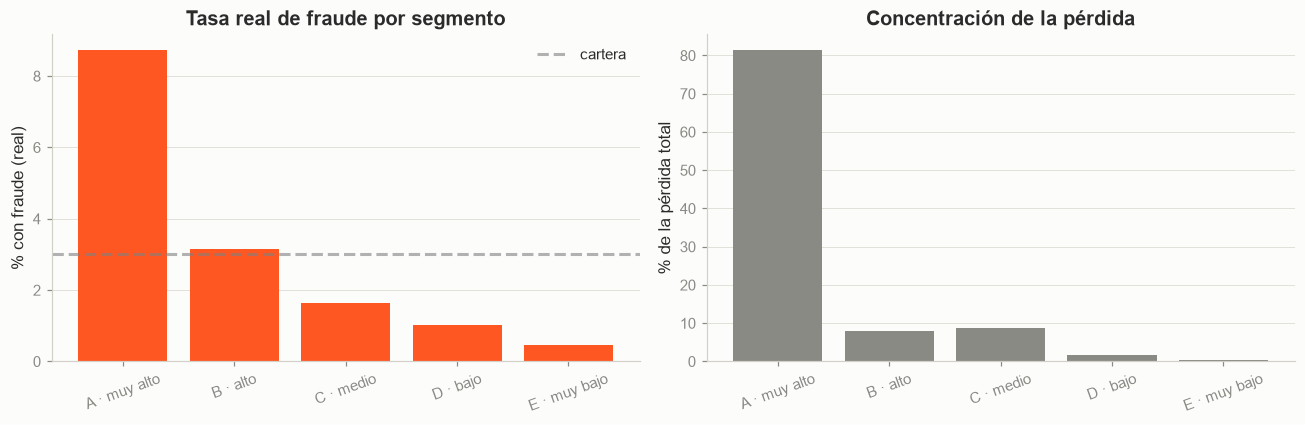

In [49]:
# ══ SALIDA 1 · Segmentación por riesgo (entregable externo) ═════════════════

# La asignación es por percentil (carga operativa estable). Se reporta además el
# rango de probabilidad y la tasa real de cada tramo, para que el nivel tenga un
# significado auditable por el procesador.
N_SEGMENTOS = 5
ETIQUETAS   = ["E · muy bajo", "D · bajo", "C · medio", "B · alto", "A · muy alto"]

cortes  = np.quantile(oof_score, np.linspace(0, 1, N_SEGMENTOS + 1)[1:-1])
seg_idx = np.digitize(oof_score, cortes)

seg = pl.DataFrame({
    "merchant_id": mid, "score": oof_score, "seg": seg_idx, "y": y,
    "tpv_total": tpv, "tpv_fraud": tpv_fraud,
    "segmento": np.array(ETIQUETAS)[seg_idx],
})

tasa_global = float(y.mean())
resumen_seg = (
    seg.group_by("seg", "segmento").agg(
        pl.len().alias("n_merchants"),
        pl.col("score").min().round(4).alias("score_desde"),
        pl.col("score").max().round(4).alias("score_hasta"),
        pl.col("y").mean().alias("tasa_fraude_real"),
        pl.col("tpv_total").sum().alias("tpv"),
        pl.col("tpv_fraud").sum().alias("perdida_real"),
    )
    .with_columns([
        (pl.col("tasa_fraude_real") / tasa_global).round(2).alias("lift"),
        (pl.col("tpv") / pl.col("tpv").sum()).alias("pct_tpv"),
        (pl.col("perdida_real") / pl.col("perdida_real").sum()).alias("pct_perdida"),
    ])
    .sort("seg", descending=True)
    .select(["segmento", "n_merchants", "score_desde", "score_hasta",
             "tasa_fraude_real", "lift", "pct_tpv", "pct_perdida"])
)
print(f"tasa de fraude de la cartera: {tasa_global:.2%}\n")
print(resumen_seg)

# VALIDACIÓN: la segmentación sirve solo si la tasa REAL crece con el nivel.
tasas = resumen_seg["tasa_fraude_real"].to_numpy()[::-1]   # de E hacia A
monotona = bool(np.all(np.diff(tasas) >= 0))
print(f"\ntasa real monótona de E a A: {monotona}  →  {[f'{t:.2%}' for t in tasas]}")
if not monotona:
    print("AVISO: la segmentación no ordena bien el riesgo, revisar antes de entregar")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
o = np.argsort(seg["seg"].to_numpy())[::-1]
etq = resumen_seg["segmento"].to_list()
axes[0].bar(etq, resumen_seg["tasa_fraude_real"].to_numpy() * 100)
axes[0].axhline(tasa_global * 100, ls="--", color="gray", alpha=0.6, label="cartera")
axes[0].set(ylabel="% con fraude (real)", title="Tasa real de fraude por segmento")
axes[0].legend(); axes[0].tick_params(axis="x", rotation=20)
axes[1].bar(etq, resumen_seg["pct_perdida"].to_numpy() * 100, color="C1")
axes[1].set(ylabel="% de la pérdida total", title="Concentración de la pérdida")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.show()

In [50]:
# Dataset unificado

agg_full = (
    pl.scan_parquet(DATA / "txn_sample.parquet")
    .group_by("merchant_id").agg([
        pl.len().alias("n_txn"),
        pl.col("amount").sum().alias("tpv_total"),
        pl.when(pl.col("is_fraud") == 1).then(pl.col("amount")).otherwise(0).sum().alias("tpv_fraud"),
    ])
    .collect()
)

feat_all = pl.read_parquet(FEATURES)
score_fuera = modelo_full.predict_proba(feat_all.select(X_cols).to_numpy())[:, 1]

scores_universo = dict(zip(mid.tolist(), oof_score.tolist()))
seg_universo    = dict(zip(mid.tolist(), seg["segmento"].to_list()))

ids_all = feat_all["merchant_id"].to_list()
en_univ = np.array([m in scores_universo for m in ids_all])
score_final = np.array([scores_universo.get(m, s) for m, s in zip(ids_all, score_fuera)])


seg_final = np.array(ETIQUETAS)[np.digitize(score_final, cortes)]

# Pérdida esperada = P(riesgo) × TPV × tasa de pérdida de un positivo.

loss_rate_full = float(data["fraud_rate_tpv"].to_numpy()[y == 1].mean())

merchant_risk = (
    pl.DataFrame({
        "merchant_id":        ids_all,
        "score_riesgo":       score_final,
        "segmento_riesgo":    seg_final,
        "en_universo_modelo": en_univ,
    })
    .join(feat_all.select(["merchant_id", "industry_mcc", "tenure_days"]), on="merchant_id", how="left")
    .join(agg_full, on="merchant_id", how="left")
    .with_columns([
        pl.col("n_txn").fill_null(0),
        pl.col("tpv_total").fill_null(0.0),
        (pl.col("score_riesgo") * pl.col("tpv_total").fill_null(0.0) * loss_rate_full)
            .alias("perdida_esperada"),
    ])
    .sort("perdida_esperada", descending=True)
)

merchant_risk.write_parquet(DATA / "merchant_risk.parquet")

print(f"tasa de pérdida de un positivo: {loss_rate_full:.4%}")
print(f"merchant_risk: {merchant_risk.shape} → data/merchant_risk.parquet")
print(f"  en universo modelable (n_txn >= {ACTIVITY_FLOOR}): {int(en_univ.sum()):,}")
print(f"  fuera del universo (score menos confiable):        {int((~en_univ).sum()):,}")
print(f"\npérdida esperada total de la cartera: {merchant_risk['perdida_esperada'].sum():,.0f}")
print(f"concentrada en el top 100: {merchant_risk['perdida_esperada'].head(100).sum() / merchant_risk['perdida_esperada'].sum():.1%}")
print()
print(merchant_risk.head(10))

tasa de pérdida de un positivo: 4.0807%
merchant_risk: (40265, 10) → data/merchant_risk.parquet
  en universo modelable (n_txn >= 10): 23,083
  fuera del universo (score menos confiable):        17,182

pérdida esperada total de la cartera: 13,486,738
concentrada en el top 100: 49.6%

shape: (10, 10)
┌────────────┬────────────┬───────────┬───────────┬───┬────────┬───────────┬───────────┬───────────┐
│ merchant_i ┆ score_ries ┆ segmento_ ┆ en_univer ┆ … ┆ n_txn  ┆ tpv_total ┆ tpv_fraud ┆ perdida_e │
│ d          ┆ go         ┆ riesgo    ┆ so_modelo ┆   ┆ ---    ┆ ---       ┆ ---       ┆ sperada   │
│ ---        ┆ ---        ┆ ---       ┆ ---       ┆   ┆ u32    ┆ f64       ┆ f64       ┆ ---       │
│ str        ┆ f64        ┆ str       ┆ bool      ┆   ┆        ┆           ┆           ┆ f64       │
╞════════════╪════════════╪═══════════╪═══════════╪═══╪════════╪═══════════╪═══════════╪═══════════╡
│ M27E953913 ┆ 0.382826   ┆ A · muy   ┆ true      ┆ … ┆ 1418   ┆ 4.3458e7  ┆ 44435.507 ┆ 678